# 5 - Neo-Riemannian Transformations

In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [4]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
import re

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia
from Importables import tonnetz_utils as t

In [5]:
metadata = g.load_metadata()

## Test: One piece

In [8]:
test = metadata[metadata['fnames'] == 'Final Thought - Kamasi Washington']
labels = g.load_labels(test)
labels.head() 

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,harmony_layer,label,regex_match,artist,workTitle,fnames,rel_paths,recording_year,time,ILS
0,1,1,0,0,116.0,0.0,0,2/2,1,1,3,Dm,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,1.0,"[D, F, A]"
1,30,30,116,116,8.0,0.0,0,2/2,1,1,3,E-,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,30.0,"[E-, G, B-]"
2,32,32,124,124,8.0,0.0,0,2/2,1,1,3,Dm,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,32.0,"[D, F, A]"
3,34,34,132,132,8.0,0.0,0,2/2,1,1,3,E-,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,34.0,"[E-, G, B-]"
4,36,36,140,140,8.0,0.0,0,2/2,1,1,3,F,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,36.0,"[F, A, C]"


In [10]:
transformations, exceptions = t.transformation(labels)
transformations.value_counts(subset=['transformation']).reset_index(name='count')

,transformation,count
0,N/A,14
1,N,2
2,R,2


## All :)))))

In [125]:
labels = g.load_labels(metadata)
transformations, exceptions = t.transformation(labels) 

In [126]:
transformations.value_counts(subset=['transformation']).reset_index(name='count') 

,transformation,count
0,N/A,17804
1,N,3030
2,P,835
3,R,376
4,H,296
5,L,205
6,S,189


### Exceptions

In [128]:
exceptions = labels[labels['label'].isin(exceptions)].value_counts(subset=['label']).reset_index(name='count')
exceptions

,label,count
0,Cm69,134
1,E13no3,27
2,F13no3,27
3,E-13no3,15
4,G#dim,14
5,D13sus4,13
6,Edim,11
7,Do,8
8,A-9sus4,6
9,D-M7no5,6


### Group by year

In [132]:
transformations_cut = transformations[transformations['transformation'] != 'N/A'].copy()
transformations_cut = transformations_cut[transformations_cut['recording_year'].notna()]

1930-1940: snum: [1.18603863 3.18471338 0.54794521 0.         0.48780488 0.        ]
1950-1960: snum: [55.60826838 31.46496815 36.16438356 36.36363636 54.63414634 57.37704918]
1970-1980: snum: [14.06302948 20.76433121 25.75342466  7.1969697   2.43902439  4.3715847 ]
1990-2000: snum: [16.1640122  38.21656051 24.10958904 29.54545455 20.48780488 29.50819672]
2010-2020: snum: [12.9786513   6.36942675 13.42465753 26.89393939 21.95121951  8.7431694 ]


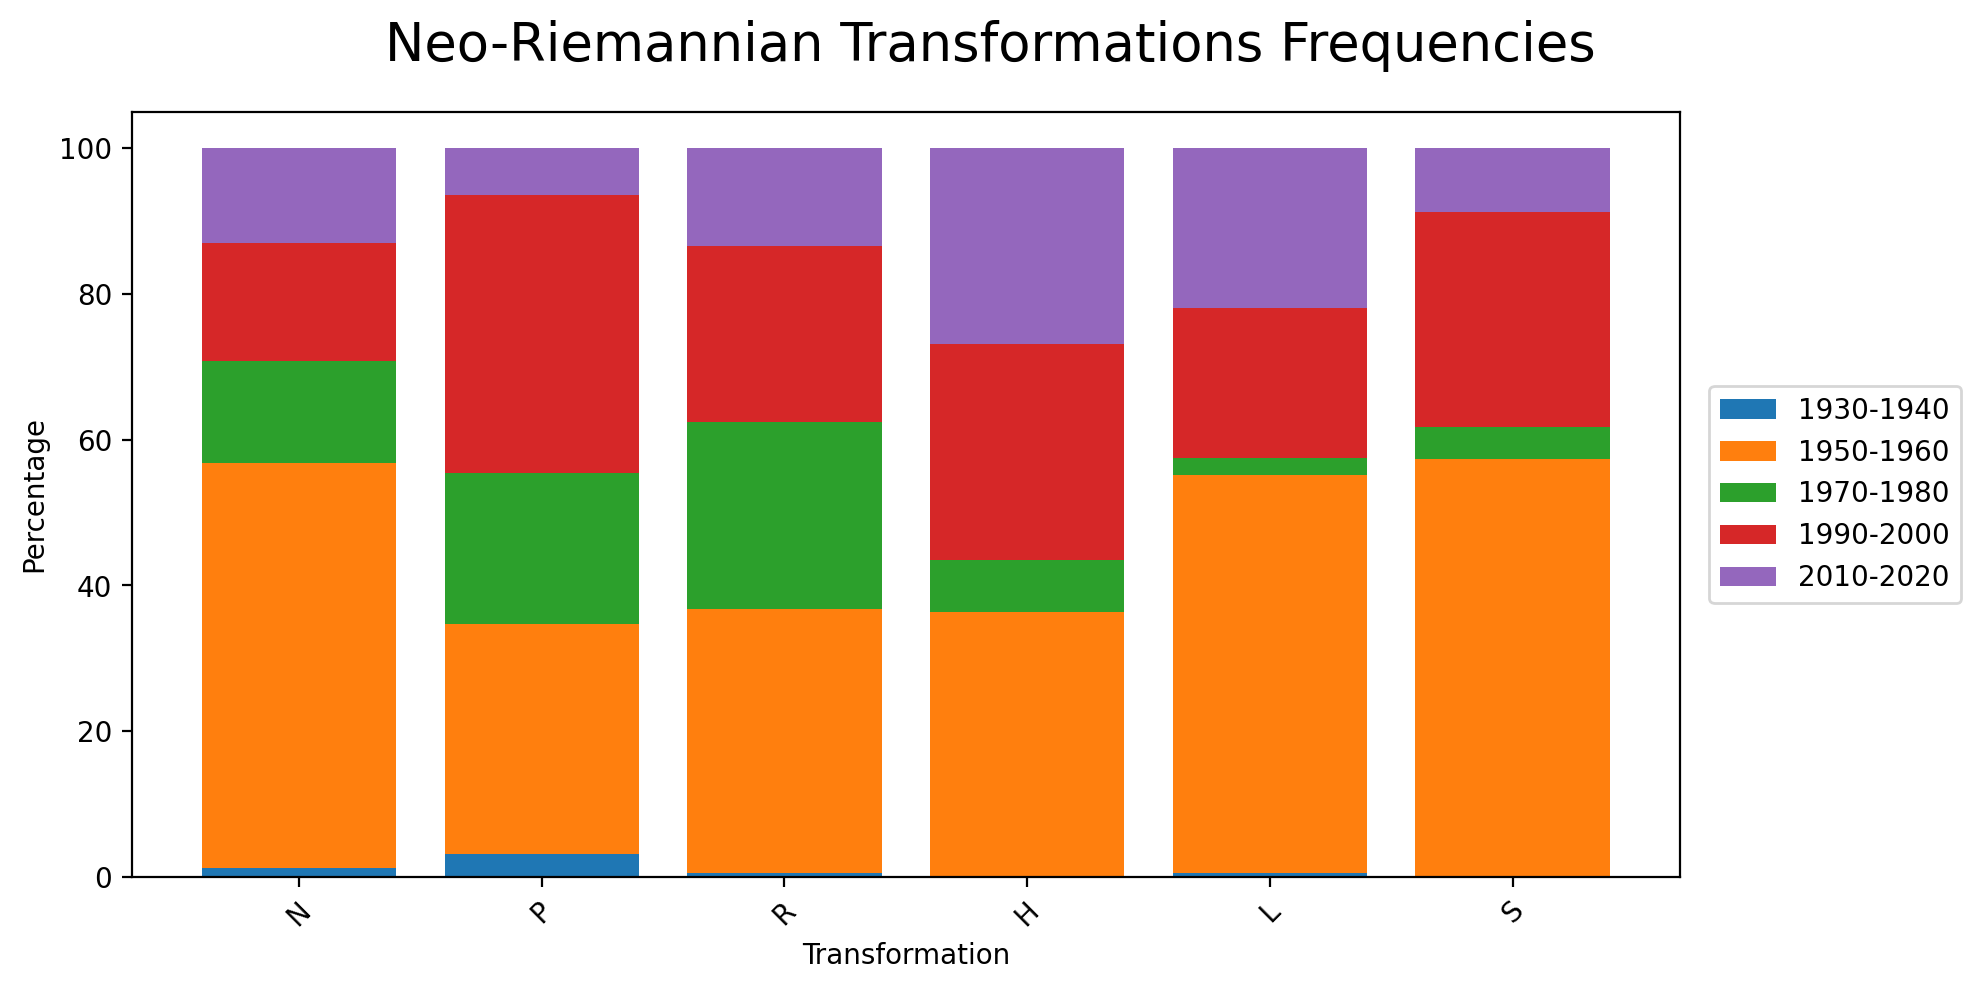

In [134]:
bins = np.arange(1930, 2040, 20) 
bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]

transformations_cut['year_bin'] = pd.cut(transformations_cut['recording_year'], bins=bins, labels=bin_labels, right=False)

tot_counts = transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['count']
x = transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['transformation']
num_bins = len(x)

fig, ax = plt.subplots(figsize=(10, 5))
current_itn = np.zeros(num_bins)
for years in bin_labels:
    transformation_years = transformations_cut[transformations_cut['year_bin']== years]
    transformations_years_grouped = (
        transformation_years.groupby('transformation')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_years_grouped['count'] * 100 / tot_counts
    y = np.array(y)
    print(f"{years}: snum: {y}")

    ax.bar(x, y, bottom = current_itn, label=years)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Transformation')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Neo-Riemannian Transformations Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()

1930-1940: snum: [0.98271772 0.50955414 0.54794521 0.         0.         0.        ]
1940-1950: snum: [0.20332091 2.67515924 0.         0.         0.48780488 0.        ]
1950-1960: snum: [36.66553711 19.36305732 22.46575342 25.75757576 38.04878049 33.87978142]
1960-1970: snum: [18.94273128 12.10191083 13.69863014 10.60606061 16.58536585 23.49726776]
1970-1980: snum: [ 9.42053541 13.12101911 19.45205479  6.06060606  2.43902439  4.3715847 ]
1980-1990: snum: [4.64249407 7.6433121  6.30136986 1.13636364 0.         0.        ]
1990-2000: snum: [ 6.67570315  8.66242038  8.76712329 17.8030303   6.34146341 17.4863388 ]
2000-2010: snum: [ 9.48830905 29.55414013 15.34246575 11.74242424 14.14634146 12.02185792]
2010-2020: snum: [12.9786513   6.36942675 13.42465753 26.89393939 21.95121951  8.7431694 ]


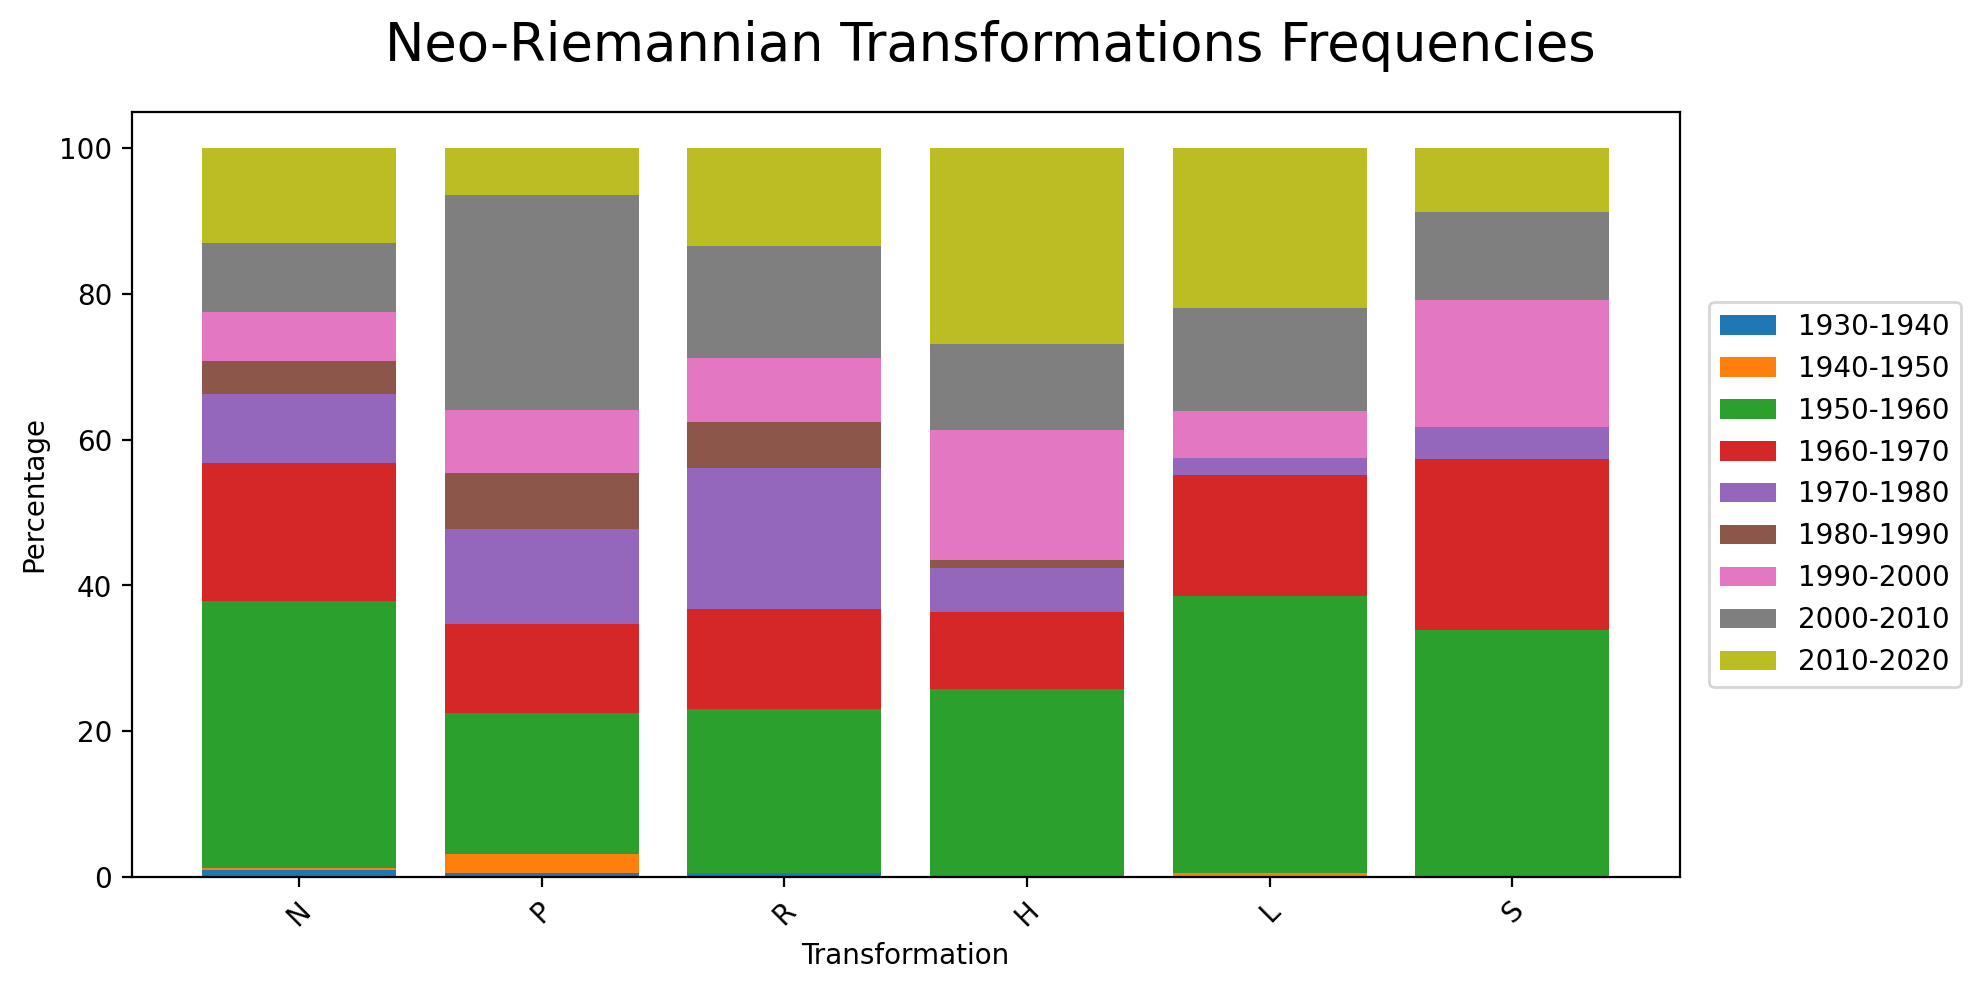

In [136]:
bins = np.arange(1930, 2030, 10) 
bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]

transformations_cut['year_bin'] = pd.cut(transformations_cut['recording_year'], bins=bins, labels=bin_labels, right=False)

tot_counts = transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['count']
x = transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['transformation']
num_bins = len(x)

fig, ax = plt.subplots(figsize=(10, 5))
current_itn = np.zeros(num_bins)

for years in bin_labels:
    transformation_years = transformations_cut[transformations_cut['year_bin']== years]
    transformations_years_grouped = (
        transformation_years.groupby('transformation')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_years_grouped['count'] * 100 / tot_counts
    y = np.array(y)
    print(f"{years}: snum: {y}")

    ax.bar(x, y, bottom = current_itn, label=years)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Transformation')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Neo-Riemannian Transformations Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

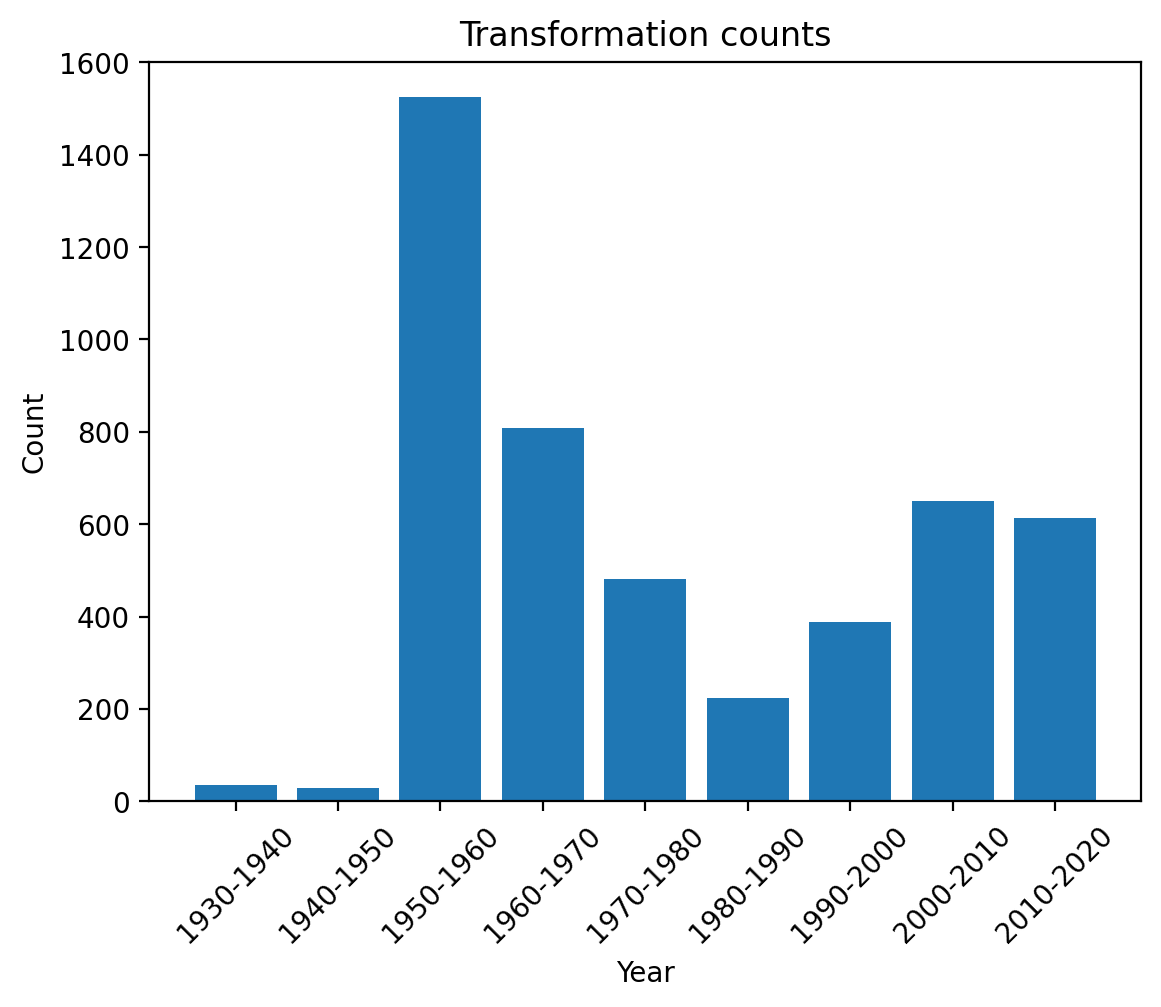

In [138]:
transformations_cut['year_bin'] = pd.Categorical(transformations_cut['year_bin'], categories=bin_labels, ordered=True)
counts = transformations_cut.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
y = counts['count']
x = counts['year_bin']
plt.bar(x, y)
plt.title('Transformation counts')
plt.ylabel('Count')
plt.xlabel('Year')
plt.xticks(x,rotation=45)
plt.show


2010-2020: snum: [  29    6 1082  559  278  137  197  280  383]
2010-2020: snum: [  4  21 152  95 103  60  68 232  50]
2010-2020: snum: [ 2  0 82 50 71 23 32 56 49]
2010-2020: snum: [ 0  0 68 28 16  3 47 31 71]
2010-2020: snum: [ 0  1 78 34  5  0 13 29 45]
2010-2020: snum: [ 0  0 62 43  8  0 32 22 16]


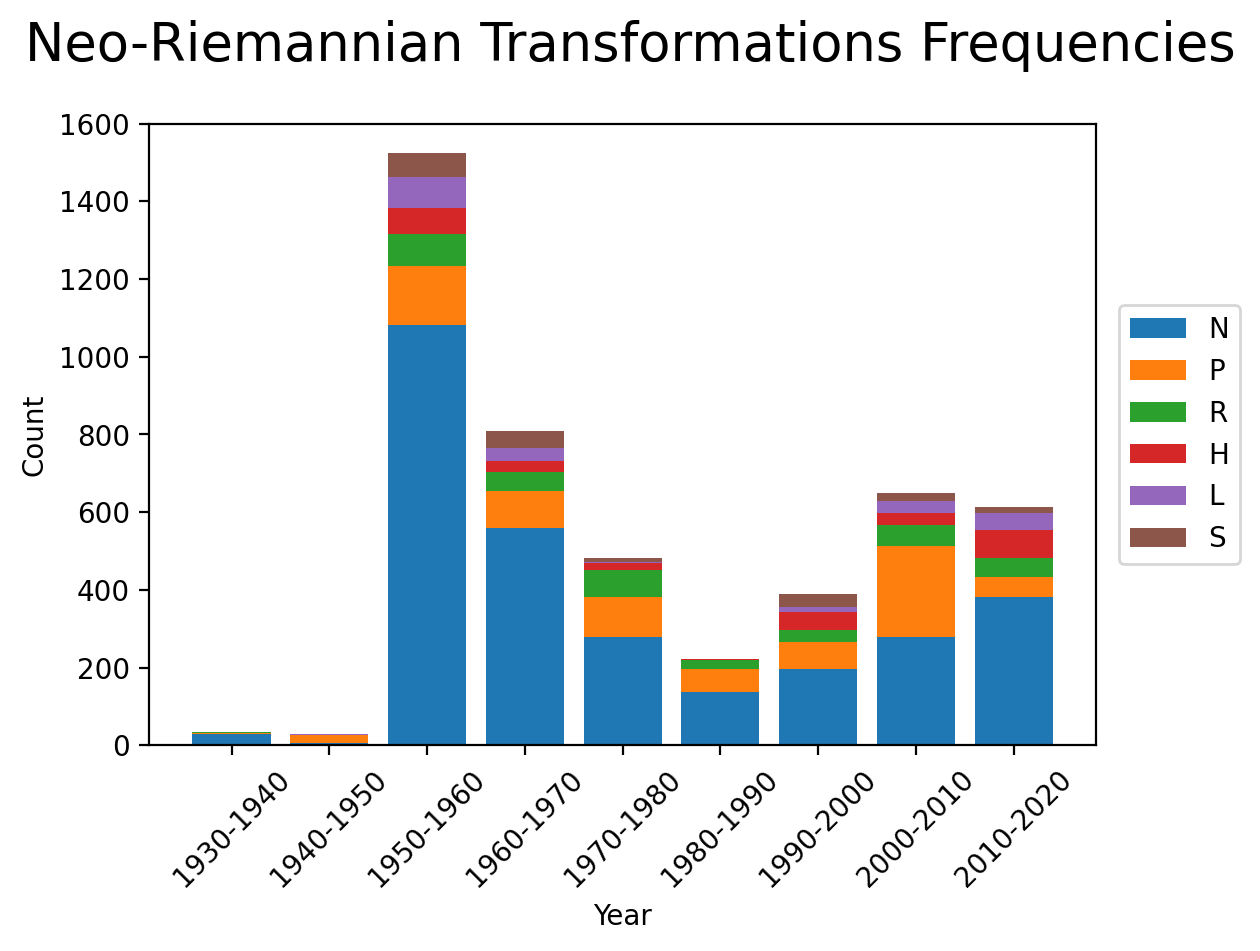

In [140]:
# bins = np.arange(1930, 2030, 10) 
# bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]

# transformations_cut['year_bin'] = pd.cut(transformations_cut['recording_year'], bins=bins, labels=bin_labels, right=False)

# tot_counts = transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['count']
x = bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)

for transformation in transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = transformations_cut[transformations_cut['transformation']== transformation]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y)
    print(f"{years}: snum: {y}")

    ax.bar(x, y, bottom = current_itn, label=transformation)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Neo-Riemannian Transformations Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()

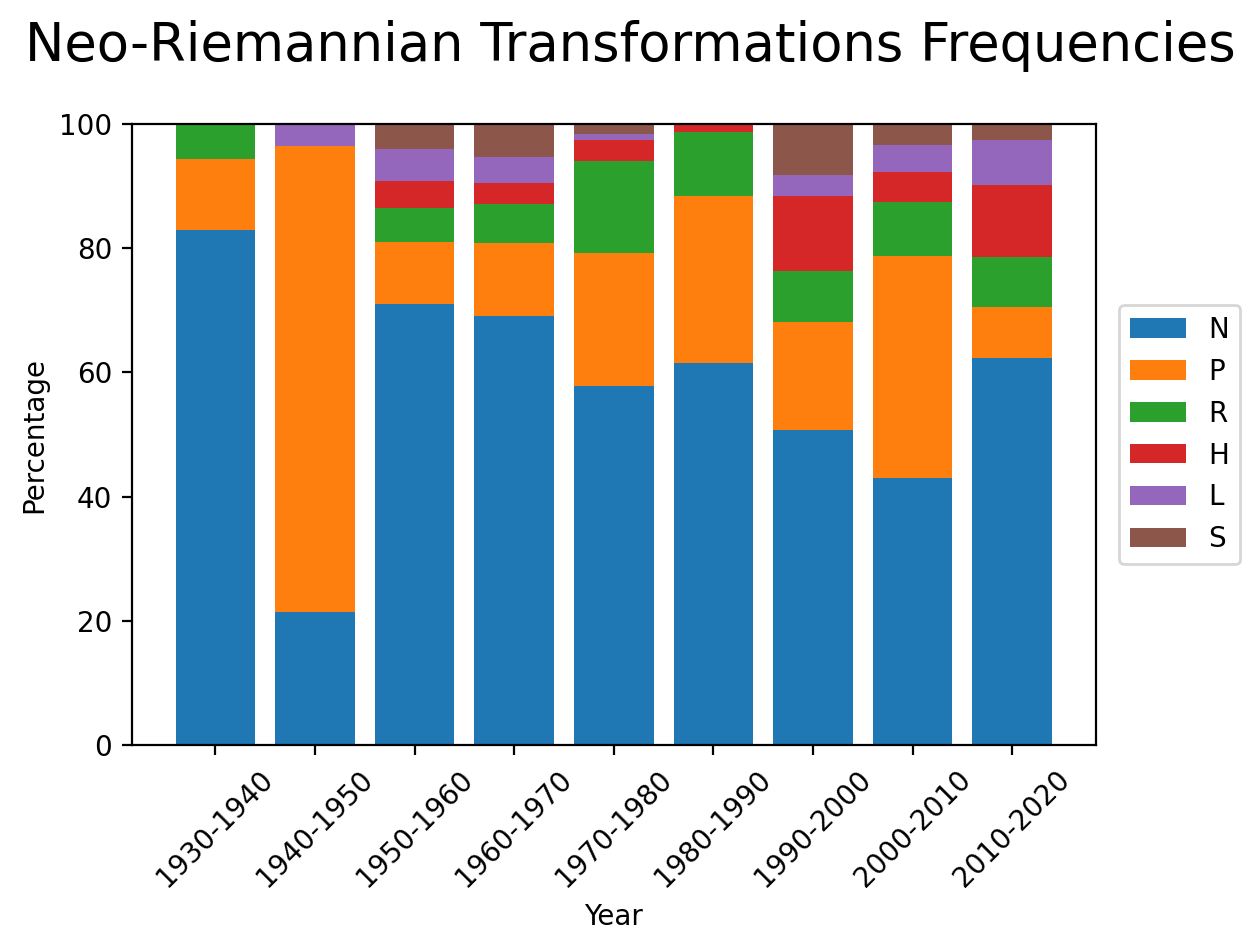

In [142]:
transformations_cut['year_bin'] = pd.Categorical(transformations_cut['year_bin'], categories=bin_labels, ordered=True)
tot_counts = transformations_cut.value_counts(subset=['year_bin']).reset_index(name='count')
tot_counts = tot_counts.sort_values('year_bin')['count']

x = bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)

for transformation in transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = transformations_cut[transformations_cut['transformation']== transformation]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count']
    y = np.array(y) * 100 / tot_counts
    #print(f"{transformation}: snum: {y}")

    ax.bar(x, y, bottom = current_itn, label=transformation)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Neo-Riemannian Transformations Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()

In [214]:
def plot(transformation):
    P_results = []
    
    for years in bin_labels:
        subset_year = transformations_cut[transformations_cut['year_bin'] == years]
        tot_count = subset_year.shape[0]
        # bootstrap
        sample_mean = []
        for i in range(100):
            sub_samp = subset_year.sample(frac=1, replace=True)
            P_count = sub_samp[sub_samp['transformation'] == transformation].shape[0]
            avg = 100 * P_count / tot_count
            sample_mean.append(avg)
    
        mean_estimate = np.mean(sample_mean)
        ci_lower = np.percentile(sample_mean, 2.5)
        ci_upper = np.percentile(sample_mean, 97.5)
    
        P_results.append({
            'year_bin': years,
            'mean': mean_estimate,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })
        
    P_results = pd.DataFrame(P_results)
    
    yerr = [
        P_results['mean'] - P_results['ci_lower'],
        P_results['ci_upper'] - P_results['mean']
    ]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.errorbar(P_results['year_bin'], P_results['mean'], yerr=yerr, capsize=5, color='skyblue')
    
    ax.set_xlabel('Year')
    ax.set_ylabel(f'% of {transformation} Transformations')
    ax.set_title(f'Bootstrap Estimates of {transformation} Transformation Proportions with 95% CIs')
    ax.set_ylim(0, 100)
    ax.set_xticklabels(P_results['year_bin'], rotation=45)
    
    plt.tight_layout()
    plt.savefig(f"../Results/{transformation}Transformation")
    plt.show()

    return P_results['mean']

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/1676963758.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


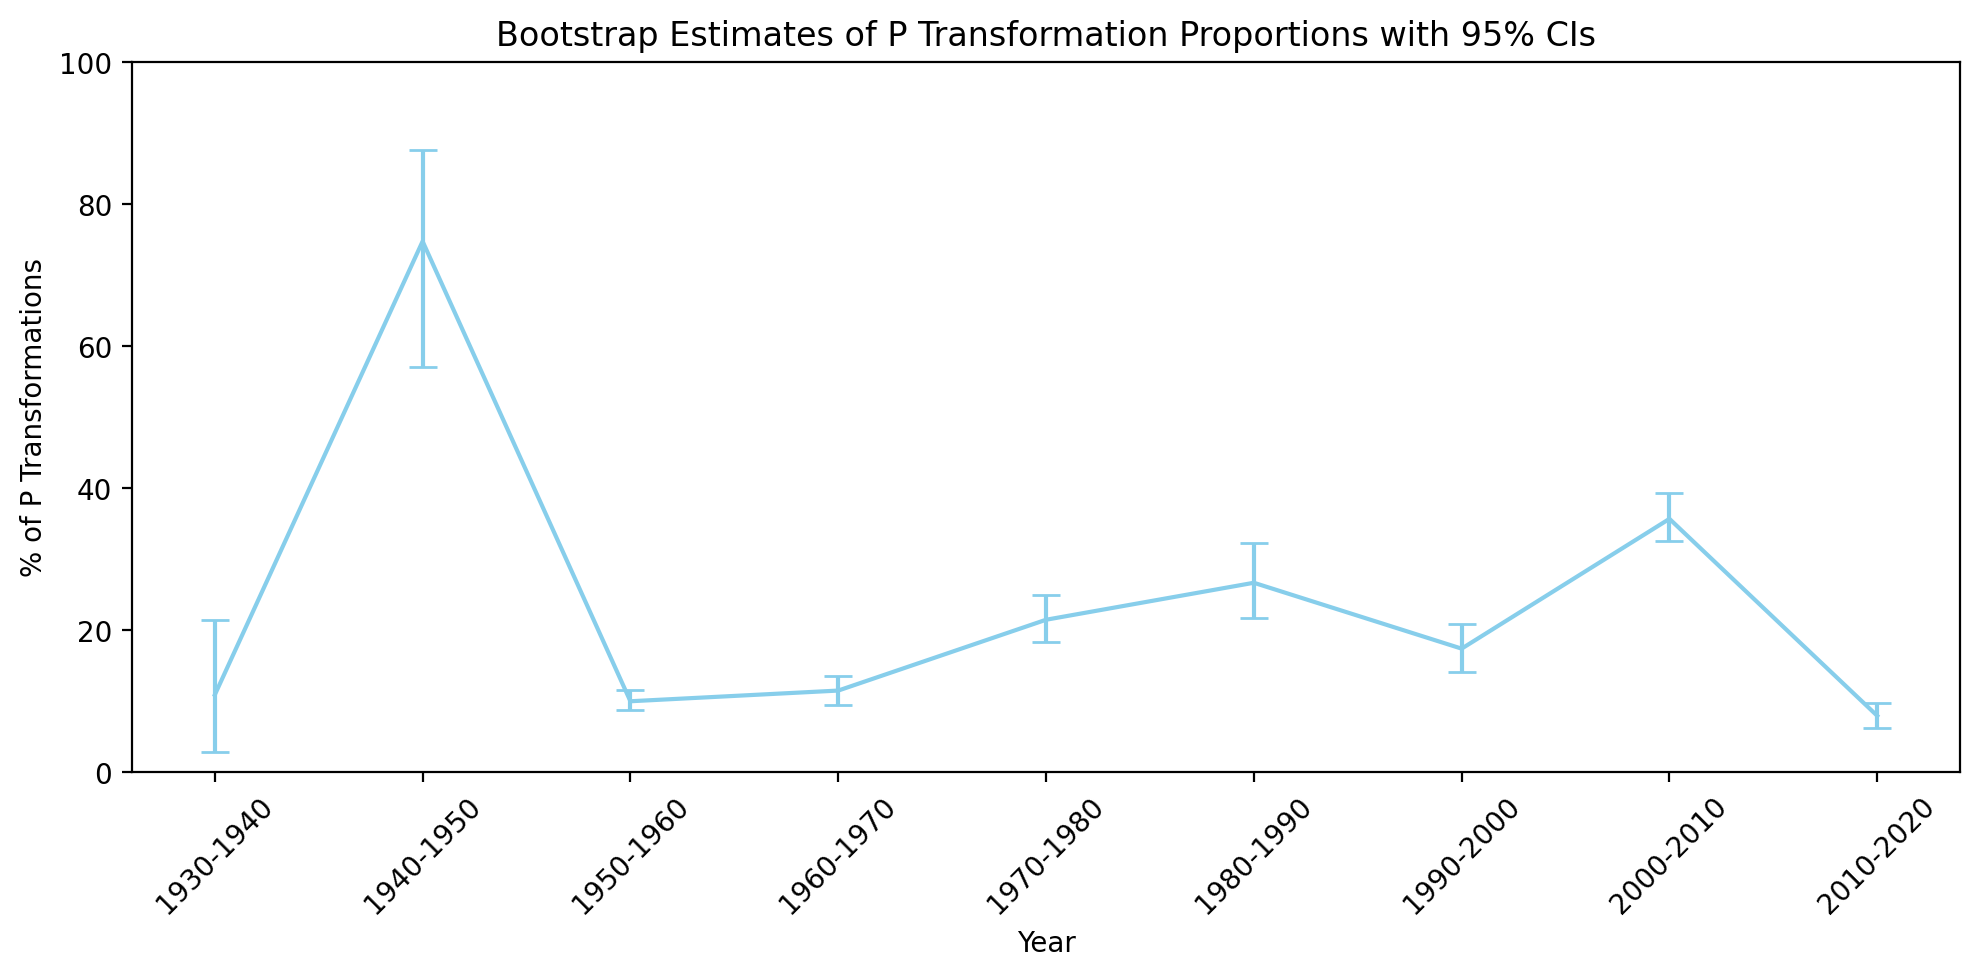

In [220]:
P = plot('P')

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/1676963758.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


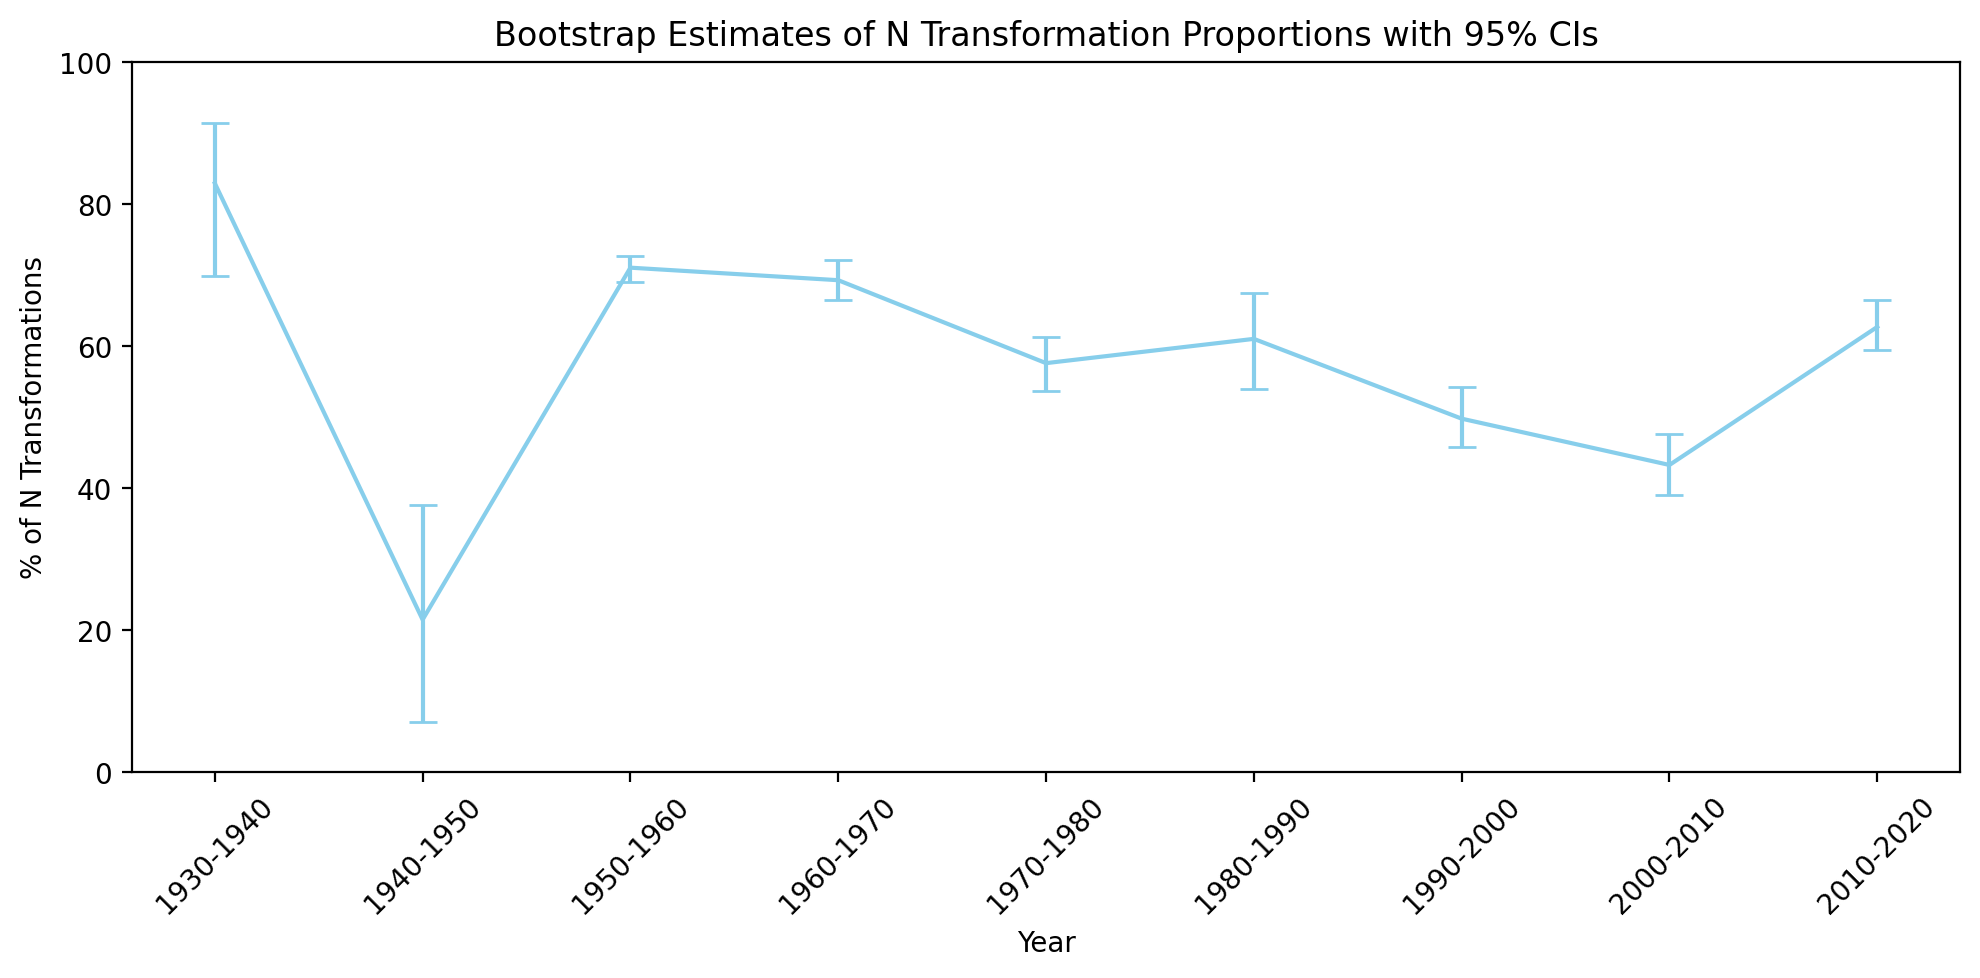

In [222]:
N = plot('N')

In [224]:
from scipy.stats import spearmanr
correlation, p_value = spearmanr(N, P)
print("Spearman correlation:", correlation)
print("p-value:", p_value)

Spearman correlation: -0.8166666666666667
p-value: 0.007224785246358786


In [226]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(N, P)
print("Pearson correlation:", corr)
print("p-value:", p_value) 

Pearson correlation: -0.8901533321820457
p-value: 0.0012971048410566116


## Group by artist

Other: snum: [53.69149637 48.62275449 60.90425532 63.17567568 54.14634146 65.60846561]
Bob Mintzer: snum: [4.28477258 1.55688623 0.26595745 0.67567568 1.46341463 1.58730159]
Paul Desmond: snum: [7.77851022 1.91616766 6.91489362 6.41891892 8.29268293 3.17460317]
Chet Baker, Paul Desmond: snum: [1.48319051 0.         5.31914894 0.         0.         0.        ]
Chet Baker: snum: [4.38365194 2.63473054 8.77659574 1.35135135 0.48780488 0.        ]
Miles Davis: snum: [6.78971655 3.47305389 5.58510638 7.43243243 0.         8.99470899]
Dexter Gordon: snum: [ 7.54779169 12.21556886  3.9893617   3.71621622  0.48780488 10.05291005]
Miles Davis, John Coltrane: snum: [0.06591958 1.91616766 2.39361702 8.78378378 0.         0.        ]
Sonny Rollins: snum: [ 5.89980224  1.67664671  0.          1.68918919 33.17073171  0.        ]
Sonny Rollins, Miles Davis: snum: [2.07646671 2.51497006 0.         2.36486486 0.         0.        ]
John Coltrane, Sonny Rollins: snum: [1.58206987 0.         0.         0

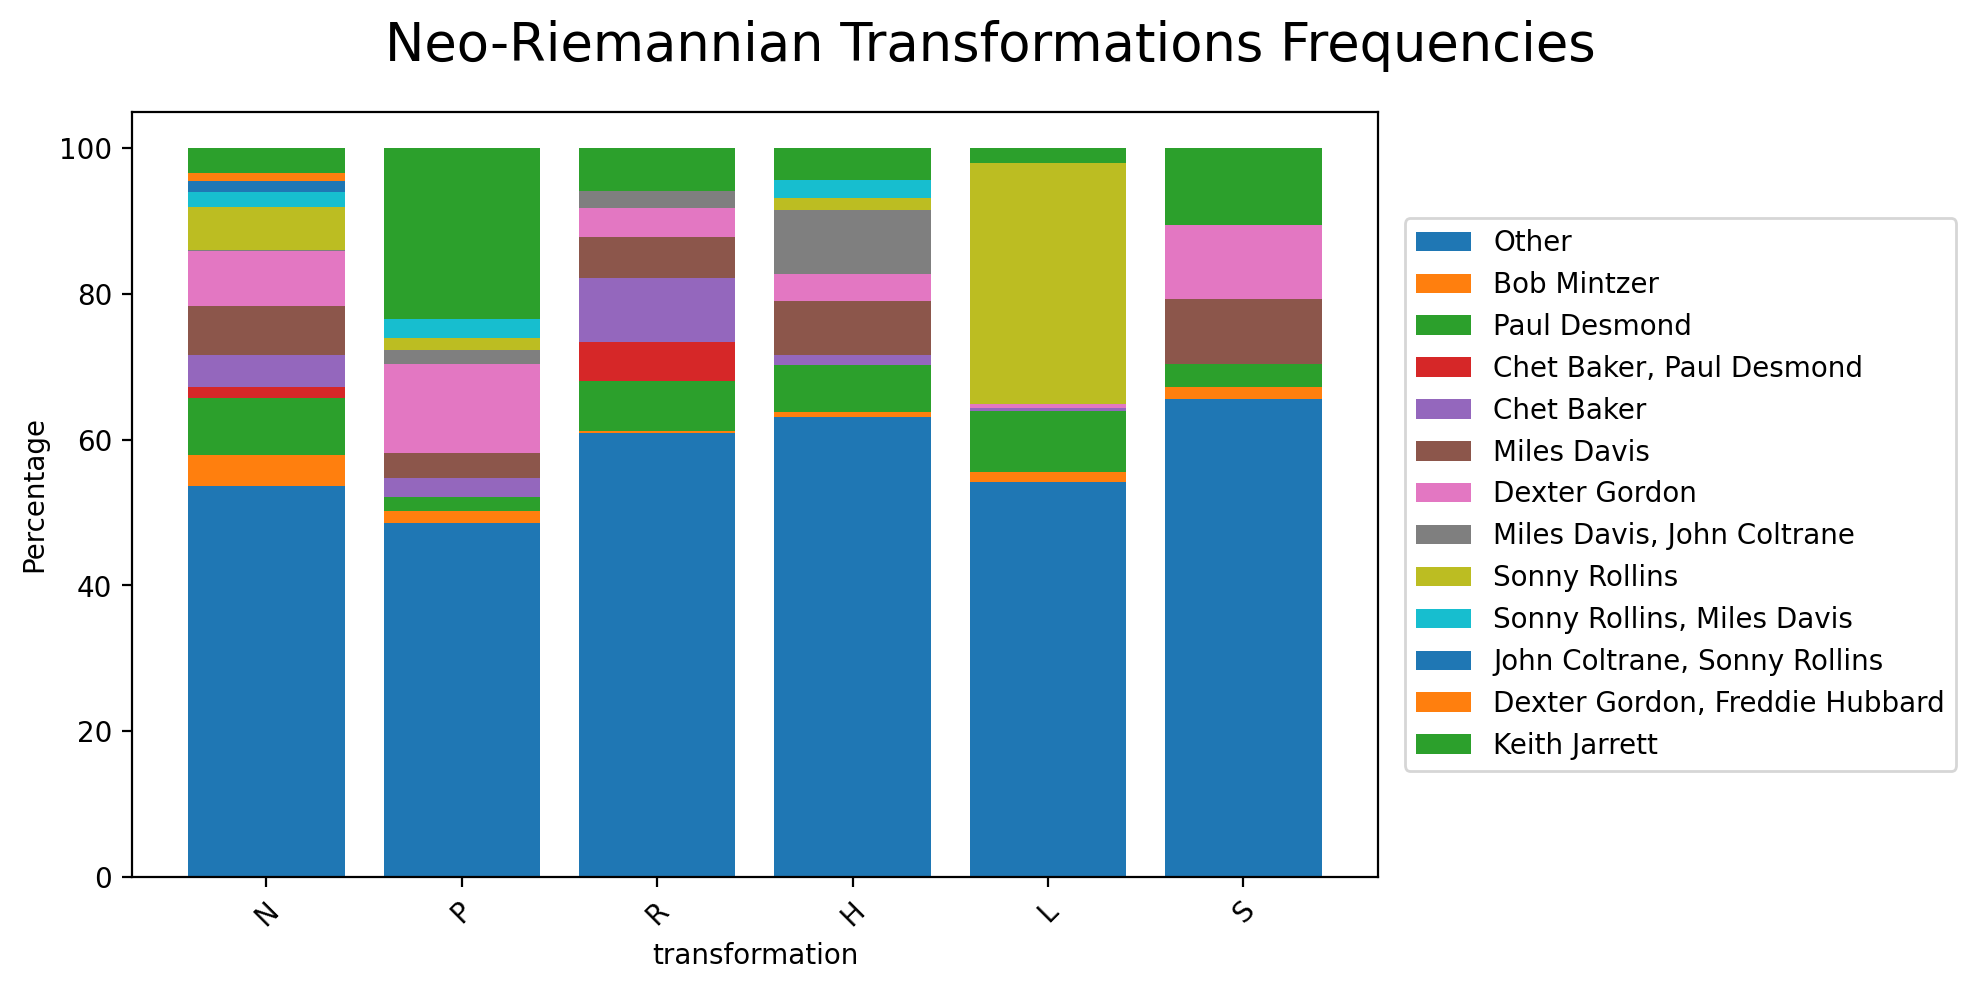

In [340]:
import re

grouped_artists = labels['artist'].value_counts()
artists_labels = grouped_artists.index[:8]

pattern = '|'.join(re.escape(artist) for artist in artists_labels)
labels['artist'] = labels['artist'].where(labels['artist'].str.contains(pattern, na=False), 'Other')

transformations_artists, exceptions_artists = t.transformation(labels) 
transformations_artists = transformations_artists[transformations_artists['transformation'] != 'N/A']

tot_counts = transformations_artists.value_counts(subset=['transformation']).reset_index(name='count')['count']
x = transformations_artists.value_counts(subset=['transformation']).reset_index(name='count')['transformation']
num_bins = len(x)

fig, ax = plt.subplots(figsize=(10, 5))
current_itn = np.zeros(num_bins)
for artist in transformations_artists['artist'].unique():
    transformation_artist = transformations_artists[transformations_artists['artist']== artist]
    transformations_artist_grouped = (
        transformation_artist.groupby('transformation')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_artist_grouped['count'] * 100 / tot_counts
    y = np.array(y)
    print(f"{artist}: snum: {y}")

    ax.bar(x, y, bottom = current_itn, label=artist)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('transformation')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Neo-Riemannian Transformations Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show() 

<function matplotlib.pyplot.show(close=None, block=None)>

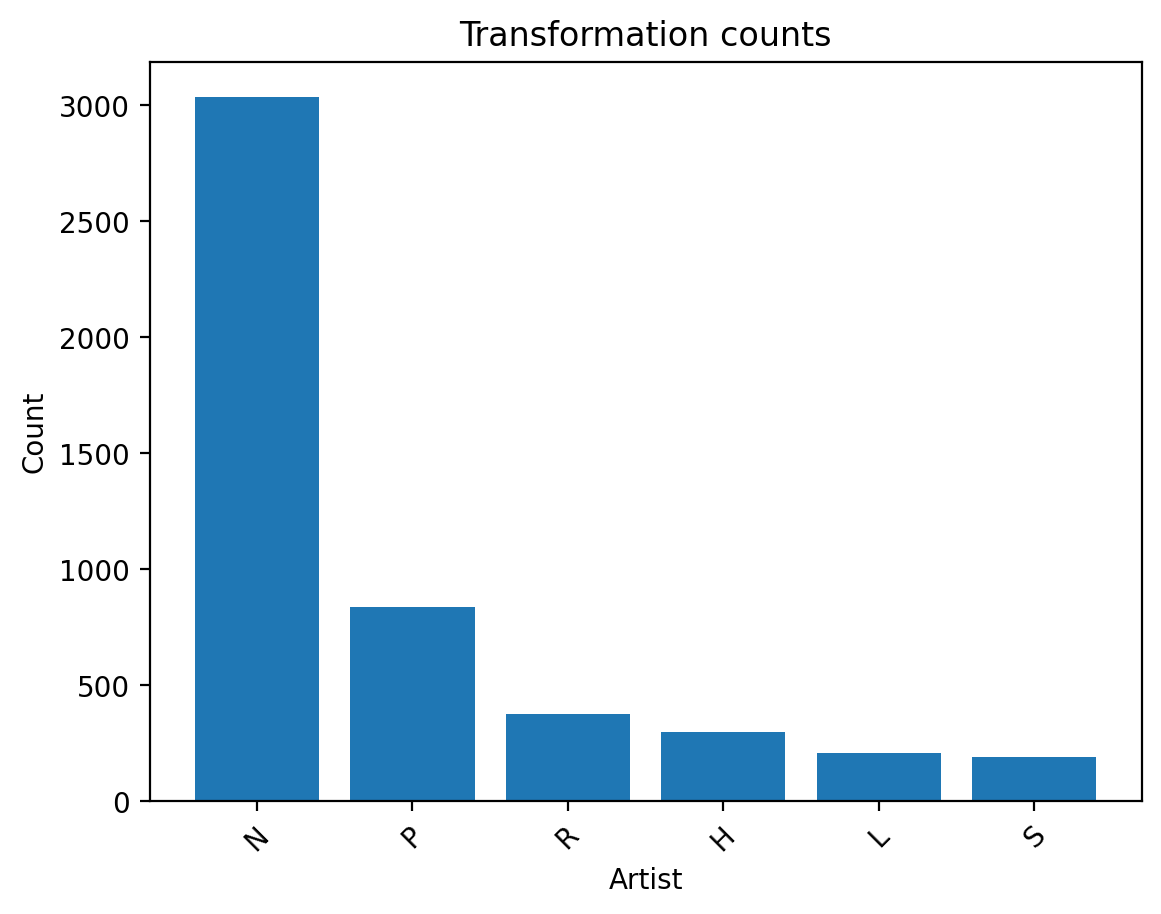

In [341]:
tot_transformations_artists = transformations_artists[transformations_artists['transformation'] != 'N/A']
y = tot_transformations_artists.value_counts(subset=['transformation']).reset_index(name='count')['count']
x = tot_transformations_artists.value_counts(subset=['transformation']).reset_index(name='count')['transformation']
plt.bar(x, y)
plt.title('Transformation counts')
plt.ylabel('Count')
plt.xlabel('Artist')
plt.xticks(x,rotation=45)
plt.show